<div style="padding: 20px; background-color: #fff5f5; border-left: 10px solid #157fe2ff; border-radius: 5px;">
    <h1 style="color: #157fe2ff; margin-bottom: 5px;">Interest Rate Transmission & GDP Factor Model</h1>
    <p style="font-style: italic; color: #2a2929ff;"><b>Domain:</b> Monetary Policy Analysis | <b>Tools:</b> Pandas, openpyxl, Plotly, python-pptx</p>
    <hr style="border: 0.5px solid #157fe2ff;">
    <div style="color: #2a2929ff;"><b>Scope:</b> Synchronizing disparate data scales (Trillions vs. Percentages) to quantify the impact of Federal Reserve policy on Real GDP growth.</p>
</div>

In [1]:
# Importing the libraries:
import pandas as pd
import os
import requests
import numpy as np
from datetime import datetime
from dotenv import load_dotenv
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment
import plotly.graph_objects as go
from pptx import Presentation
from pptx.util import Inches
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Loading Enironment variable:
load_dotenv(override=True)
API_KEY = os.getenv("FRED_API_KEY")

In [7]:
# FRED API Calling Function:

def fetch_macro_series(series_id, label):
    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {"series_id":series_id, "api_key": API_KEY, "file_type": "json"}

    try:
        response = requests.get(url, params = params, timeout= 15)
        response.raise_for_status()
        data = response.json()
        # print("DATA::", data)
        df = pd.DataFrame(data["observations"])[["date", "value"]]

        df["value"] = pd.to_numeric(df["value"], errors="coerce")
        df["date"] = pd.to_datetime(df["date"])

        return df.dropna().rename(columns= {"value": label})
    except Exception as e:
        print(f"Error Fetching Data {series_id}: {e}")
        return None


In [10]:
# Data Frames for: GDP (Qyarterly) | FEDFUNDS (Monthly Interest Rate):
df_gdp = fetch_macro_series("GDP", "Real_GDP")
df_rates = fetch_macro_series("FEDFUNDS", "Fed_Rates")

print(f"GDP::\n {df_gdp.head()} \nRATES::\n{df_rates.head()}")

GDP::
         date  Real_GDP
4 1947-01-01   243.164
5 1947-04-01   245.968
6 1947-07-01   249.585
7 1947-10-01   259.745
8 1948-01-01   265.742 
RATES::
        date  Fed_Rates
0 1954-07-01       0.80
1 1954-08-01       1.22
2 1954-09-01       1.07
3 1954-10-01       0.85
4 1954-11-01       0.83


In [18]:
# Aligning frequnecies: monthly rates to quarterly mean.

# df_rates.set_index("date", inplace= True)
df_rates_q = df_rates.resample("QS").mean().reset_index()

print(f"RATES::\n{df_rates.head()}\nRATES_Q::\n{df_rates_q.head()}")

RATES::
            Fed_Rates
date                 
1954-07-01       0.80
1954-08-01       1.22
1954-09-01       1.07
1954-10-01       0.85
1954-11-01       0.83
RATES_Q::
        date  Fed_Rates
0 1954-07-01   1.030000
1 1954-10-01   0.986667
2 1955-01-01   1.343333
3 1955-04-01   1.500000
4 1955-07-01   1.940000


In [19]:
# Inner merge to align time series perfectly.s

df_factor = pd.merge(df_gdp, df_rates_q, on= "date", how= "inner")

df_factor.head()

,date,Real_GDP,Fed_Rates
0,1954-07-01,390.996,1.030000
1,1954-10-01,399.734,0.986667
2,1955-01-01,413.073,1.343333
3,1955-04-01,421.532,1.500000
4,1955-07-01,430.221,1.940000


In [20]:
# Statistical transformation (Z-Scores):
# GDP to Trillions and Rates to Percentages.

for col in ["Real_GDP", "Fed_Rates"]:
    df_factor[f"{col}_Z"] = (df_factor[col] - df_factor[col].mean()) / df_factor[col].std()

df_factor.head()

,date,Real_GDP,Fed_Rates,Real_GDP_Z,Fed_Rates_Z
0,1954-07-01,390.996,1.030000,-0.992258,-1.013736
1,1954-10-01,399.734,0.986667,-0.991193,-1.026028
2,1955-01-01,413.073,1.343333,-0.989567,-0.924857
3,1955-04-01,421.532,1.500000,-0.988535,-0.880417
4,1955-07-01,430.221,1.940000,-0.987476,-0.755608


In [22]:
# QA and Lag Test.
# Testing si todays rates correlate with GDP in next uarter (3-month lag).

df_factor["GDP_Lag_1"] = df_factor["Real_GDP_Z"].shift(-1)

correlation = df_factor["Fed_Rates_Z"].corr(df_factor["GDP_Lag_1"])

print(f"Policy Transmission Correlation (1-Quarter Lag):: {correlation:.4f}")

Policy Transmission Correlation (1-Quarter Lag):: -0.4362


In [24]:
# Exporting to Excel (OpenPyXl):
output_excel = "Macro_Factor_Analysis.xlsx"

with pd.ExcelWriter(output_excel, engine= "openpyxl") as writer:
    df_factor.tail(40).to_excel(writer, index= False, sheet_name= "Factor_Model")

    ws = writer.sheets["Factor_Model"]

    # Styling
    header_fill = PatternFill(start_color="4F81BD", end_color= "4F81BD", fill_type="solid")
    header_font = Font(color= "FFFFFF", bold= True)

    for cell in ws[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal= "center")

    print(f"Data Exported to: {output_excel}")


Data Exported to: Macro_Factor_Analysis.xlsx


In [27]:
# Exporting to PowerPoint (pptx) function:

def generate_pptx(report_name):
    prs = Presentation()

    slide = prs.slides.add_slide(prs.slide_layouts[5])
    slide.shapes.title.text = "Exhibit: Interest Rate Transmission Lag"

    #Summery text box:
    left = Inches(1); top = Inches(2); width = Inches(8); height = Inches(2)

    txBox = slide.shapes.add_textbox(left, top, width, height)

    tf = txBox.text_frame
    tf.text = f"Key Findings: The correlation between interest rates and 1-quarter lagged GDP stands at {correlation:.2f}."

    p = tf.add_paragraph()
    p.text = "This identifies the standard 'Transimission Lag' in monetary policy."

    prs.save(report_name)

    print(f"PowerPoint File Generated: {report_name}")

generate_pptx("Macro_Strategy_Deck.pptx")

PowerPoint File Generated: Macro_Strategy_Deck.pptx


In [28]:
# Visualisations

# 1. Factor Model: Rate Hikes v/s Economic Growth
fig = go.Figure()
fig.add_trace(go.Scatter(x= df_factor["date"], y = df_factor["Real_GDP_Z"], name= "GDP (Z_Score)", line= dict(color = "#1f77b4", width = 3)))

fig.add_trace(go.Scatter(x= df_factor["date"], y = df_factor["Fed_Rates_Z"], name= "Fed Rates (Z_Score)", line= dict(color = "#d62728", width = 2, dash = "dot")))

fig.update_layout(title = "<b>Factor Model: Rate Hikes v/s Economic Growth</b>", template = "plotly_white")

fig.show()


In [41]:
sns.set_theme(style= "whitegrid")
plt.rcParams["figure.figsize"] = [12, 10]
plt.rcParams['font.family'] = 'sans-serif'

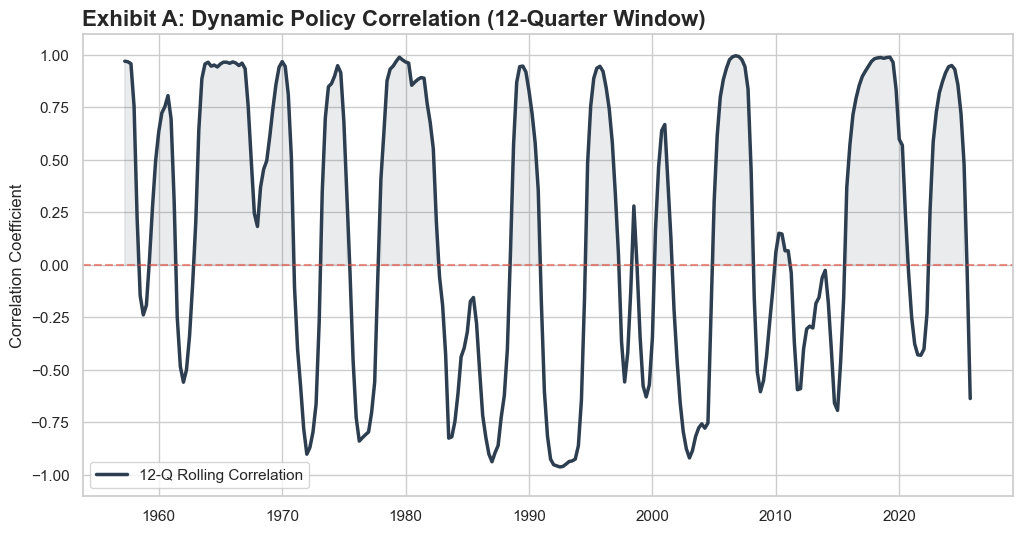

In [42]:
# Rolling Correlation between GDP and Interest Rates:

plt.figure(figsize=(12, 6))
rolling_corr = df_factor["Real_GDP_Z"].rolling(window=12).corr(df_factor["Fed_Rates_Z"])

plt.plot(df_factor["date"], rolling_corr, color="#2c3e50", linewidth=2.5, label="12-Q Rolling Correlation")
plt.axhline(0, color="#e74c3c", linestyle="--", alpha=0.6)
plt.fill_between(df_factor["date"], rolling_corr, 0, where=(rolling_corr >= 0), color='#2c3e50', alpha=0.1)

plt.title("Exhibit A: Dynamic Policy Correlation (12-Quarter Window)", fontsize=16, fontweight="bold", loc='left')
plt.ylabel("Correlation Coefficient", fontsize=12)
plt.ylim(-1.1, 1.1)
plt.legend()
plt.show()

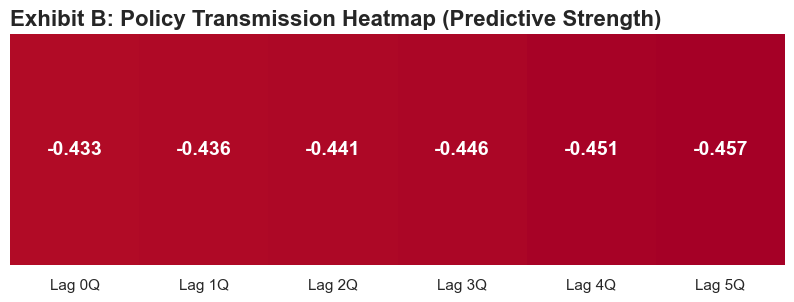

In [43]:
# ransmission Lag Heatmap:
plt.figure(figsize=(10, 3))
lags = range(6)
lag_data = {f'Lag {l}Q': [df_factor['Fed_Rates_Z'].corr(df_factor['Real_GDP_Z'].shift(-l))] for l in lags}
df_heatmap = pd.DataFrame(lag_data)

sns.heatmap(df_heatmap, annot=True, fmt=".3f", cmap='RdYlGn', center=0, cbar=False, 
            annot_kws={"size": 14, "weight": "bold"})

plt.title("Exhibit B: Policy Transmission Heatmap (Predictive Strength)", fontsize=16, fontweight="bold", loc='left')
plt.yticks([]) # Hide Y-axis as it's just one row
plt.show()

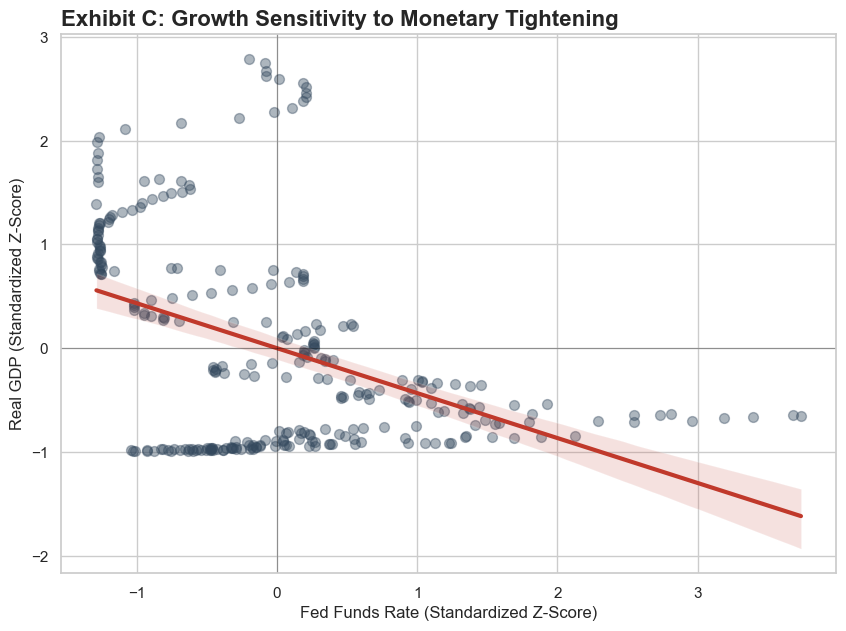

In [44]:
# Regression Sensitivity
plt.figure(figsize=(10, 7))
sns.regplot(data=df_factor, x='Fed_Rates_Z', y='Real_GDP_Z', 
            scatter_kws={'alpha':0.4, 'color':'#34495e', 's':50}, 
            line_kws={'color':'#c0392b', 'linewidth':3})

plt.title("Exhibit C: Growth Sensitivity to Monetary Tightening", fontsize=16, fontweight="bold", loc='left')
plt.xlabel("Fed Funds Rate (Standardized Z-Score)", fontsize=12)
plt.ylabel("Real GDP (Standardized Z-Score)", fontsize=12)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.3)
plt.axvline(0, color='black', linewidth=0.8, alpha=0.3)
plt.show()